In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
from PIL import Image
import os
import numpy as np

# 设置中文字体
plt.rcParams["font.family"] = ["SimHei"]
plt.rcParams['axes.unicode_minus'] = False

# 1. 数据准备
def prepare_data(batch_size=64, val_split=0.1):
    """准备MNIST数据集并创建数据加载器，包含训练集、验证集和测试集"""
    # 数据转换
    transform = transforms.Compose([
        transforms.ToTensor(),  # 转换为Tensor
        transforms.Normalize((0.1307,), (0.3081,))  # 标准化，使用MNIST数据集的均值和标准差
    ])
    
    # 加载数据集
    train_dataset = datasets.MNIST(
        root='../data', train=True, download=True, transform=transform
    )
    
    # 分割训练集为训练集和验证集
    val_size = int(val_split * len(train_dataset))
    train_size = len(train_dataset) - val_size
    train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])
    
    test_dataset = datasets.MNIST(
        root='../data', train=False, download=True, transform=transform
    )
    
    # 创建数据加载器
    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True
    )
    val_loader = DataLoader(
        val_dataset, batch_size=batch_size, shuffle=False
    )
    test_loader = DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False
    )
    
    return train_loader, val_loader, test_loader

# 2. 定义全连接神经网络模型
class FCNet(nn.Module):
    """全连接神经网络"""
    def __init__(self, input_size=784, hidden_size=128, num_classes=10):
        super(FCNet, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)  # 第一个全连接层
        self.relu = nn.ReLU()                          # 激活函数
        self.fc2 = nn.Linear(hidden_size, num_classes) # 第二个全连接层
        
    def forward(self, x):
        # 将输入展平为一维向量 (batch_size, 1, 28, 28) -> (batch_size, 784)
        x = x.view(x.size(0), -1)
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

# 3. 定义卷积神经网络模型
class CNNNet(nn.Module):
    """卷积神经网络"""
    def __init__(self, num_classes=10):
        super(CNNNet, self).__init__()
        # 第一个卷积块：卷积层 + 池化层
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # 第二个卷积块
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # 全连接层
        self.fc1 = nn.Linear(7 * 7 * 64, 128)  # 7x7是经过两次池化后的尺寸
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, num_classes)
        
    def forward(self, x):
        # 第一个卷积块
        out = self.conv1(x)
        out = self.relu1(out)
        out = self.pool1(out)  # 输出尺寸: (batch_size, 32, 14, 14)
        
        # 第二个卷积块
        out = self.conv2(out)
        out = self.relu2(out)
        out = self.pool2(out)  # 输出尺寸: (batch_size, 64, 7, 7)
        
        # 展平特征图
        out = out.view(out.size(0), -1)  # 输出尺寸: (batch_size, 7*7*64)
        
        # 全连接层
        out = self.fc1(out)
        out = self.relu3(out)
        out = self.fc2(out)
        
        return out

# 4. 验证模型（用于确定是否保存最优模型）
def validate_model(model, val_loader, device):
    """在验证集上评估模型性能"""
    model.eval()  # 设置为评估模式
    correct = 0
    total = 0
    
    with torch.no_grad():  # 禁用梯度计算
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)  # 获取预测结果
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    return accuracy

# 5. 训练模型并保存最优模型
def train_model(model, train_loader, val_loader, criterion, optimizer, device, 
                num_epochs=5, model_save_path='best_model.pth'):
    """训练模型并保存验证集上表现最好的模型"""
    model.train()  # 设置为训练模式
    losses = []
    val_accuracies = []
    best_accuracy = 0.0  # 记录最佳准确率
    
    # 创建保存模型的目录（如果不存在）
    os.makedirs(os.path.dirname(model_save_path) or '.', exist_ok=True)
    
    for epoch in range(num_epochs):
        running_loss = 0.0
        for i, (images, labels) in enumerate(train_loader):
            # 将数据移到指定设备
            images = images.to(device)
            labels = labels.to(device)
            
            # 前向传播
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # 反向传播和优化
            optimizer.zero_grad()  # 清零梯度
            loss.backward()        # 反向传播
            optimizer.step()       # 更新参数
            
            running_loss += loss.item()
            
            # 每100个批次打印一次信息
            if (i + 1) % 100 == 0:
                print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}')
        
        # 记录每个epoch的平均损失
        avg_loss = running_loss / len(train_loader)
        losses.append(avg_loss)
        
        # 在验证集上评估
        val_accuracy = validate_model(model, val_loader, device)
        val_accuracies.append(val_accuracy)
        print(f'Epoch [{epoch+1}/{num_epochs}] completed. Average Loss: {avg_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%')
        
        # 保存性能更好的模型
        if val_accuracy > best_accuracy:
            best_accuracy = val_accuracy
            torch.save(model.state_dict(), model_save_path)
            print(f'模型已更新并保存至 {model_save_path}，最佳验证准确率: {best_accuracy:.2f}%')
    
    return losses, val_accuracies, best_accuracy

# 6. 加载模型
def load_model(model_type, model_path, device=None, num_classes=10):
    """加载保存的模型参数"""
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # 初始化相应类型的模型
    if model_type == 'fc':
        model = FCNet(input_size=784, hidden_size=128, num_classes=num_classes)
    elif model_type == 'cnn':
        model = CNNNet(num_classes=num_classes)
    else:
        raise ValueError("模型类型必须是 'fc' 或 'cnn'")
    
    # 加载模型参数
    model.load_state_dict(torch.load(model_path, map_location=device))
    # 将模型移动到指定设备
    model = model.to(device)
    # 设置为评估模式
    model.eval()
    
    return model

# 7. 测试模型
def test_model(model, test_loader, device):
    """测试模型"""
    model.eval()  # 设置为评估模式
    correct = 0
    total = 0
    
    with torch.no_grad():  # 禁用梯度计算
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)  # 获取预测结果
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    print(f'Test Accuracy: {accuracy:.2f}%')
    return accuracy

# 8. 预处理自定义图片
def preprocess_image(image_path):
    """预处理用户输入的手写数字图片"""
    # 定义转换
    transform = transforms.Compose([
        transforms.Resize((28, 28)),  # 调整为28x28
        transforms.Grayscale(),       # 转换为灰度图
        transforms.ToTensor(),        # 转换为Tensor
        transforms.Normalize((0.1307,), (0.3081,))  # 标准化
    ])
    
    # 打开图片并应用转换
    image = Image.open(image_path)
    image = transform(image).unsqueeze(0)  # 添加批次维度
    
    return image

# 9. 预测自定义图片
def predict_image(model, image_path, device):
    """预测自定义手写数字图片的类别"""
    # 预处理图片
    image = preprocess_image(image_path)
    image = image.to(device)
    
    # 预测
    model.eval()
    with torch.no_grad():
        outputs = model(image)
        _, predicted = torch.max(outputs.data, 1)
        confidence = torch.nn.functional.softmax(outputs, dim=1)[0][predicted.item()].item() * 100
    
    # 返回预测结果和置信度
    return predicted.item(), confidence

# 10. 可视化结果
def visualize_results(model, test_loader, device, num_samples=5, model_name="模型"):
    """可视化部分测试结果"""
    model.eval()
    images, labels = next(iter(test_loader))
    images = images[:num_samples].to(device)
    labels = labels[:num_samples]
    
    with torch.no_grad():
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
    
    # 转换为CPU并numpy格式
    images = images.cpu().numpy()
    predicted = predicted.cpu().numpy()
    
    # 绘制图像
    plt.figure(figsize=(10, 4))
    plt.suptitle(f'{model_name}预测结果示例')
    for i in range(num_samples):
        plt.subplot(1, num_samples, i+1)
        plt.imshow(images[i].squeeze(), cmap='gray')
        plt.title(f'真实: {labels[i]}, 预测: {predicted[i]}')
        plt.axis('off')
    plt.tight_layout()
    plt.subplots_adjust(top=0.8)
    plt.show()

# 11. 可视化自定义图片预测结果
def visualize_custom_prediction(model, image_path, device, model_name="模型"):
    """可视化自定义图片及其预测结果"""
    # 加载原始图片用于显示
    original_image = Image.open(image_path).convert('L')  # 转为灰度图
    
    # 预测
    predicted_class, confidence = predict_image(model, image_path, device)
    
    # 显示图片和预测结果
    plt.figure(figsize=(6, 6))
    plt.imshow(original_image, cmap='gray')
    plt.title(f'{model_name}预测结果: {predicted_class}, 置信度: {confidence:.2f}%')
    plt.axis('off')
    plt.show()
    
    return predicted_class, confidence

# 12. 比较两种模型的性能
def compare_models(fc_losses, fc_val_acc, cnn_losses, cnn_val_acc, fc_test_acc, cnn_test_acc):
    """比较两种模型的性能并可视化"""
    # 绘制损失曲线对比
    plt.figure(figsize=(14, 6))
    
    plt.subplot(1, 2, 1)
    plt.plot(range(1, len(fc_losses)+1), fc_losses, marker='o', color='b', label='全连接网络')
    plt.plot(range(1, len(cnn_losses)+1), cnn_losses, marker='s', color='g', label='卷积神经网络')
    plt.xlabel('Epoch')
    plt.ylabel('损失值')
    plt.title('训练损失曲线对比')
    plt.legend()
    plt.grid(True)
    
    # 绘制验证准确率曲线对比
    plt.subplot(1, 2, 2)
    plt.plot(range(1, len(fc_val_acc)+1), fc_val_acc, marker='o', color='b', label='全连接网络')
    plt.plot(range(1, len(cnn_val_acc)+1), cnn_val_acc, marker='s', color='g', label='卷积神经网络')
    plt.xlabel('Epoch')
    plt.ylabel('准确率 (%)')
    plt.title('验证集准确率曲线对比')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # 绘制测试准确率对比
    plt.figure(figsize=(8, 5))
    models = ['全连接网络', '卷积神经网络']
    accuracies = [fc_test_acc, cnn_test_acc]
    bars = plt.bar(models, accuracies, color=['blue', 'green'])
    
    # 在柱状图上添加准确率数值
    for bar, acc in zip(bars, accuracies):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{acc:.2f}%', ha='center', va='bottom')
    
    plt.ylim(0, 100)
    plt.ylabel('测试集准确率 (%)')
    plt.title('两种模型测试集准确率对比')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
    
    # 打印总结
    print("\n模型性能总结:")
    print(f"全连接网络 - 测试集准确率: {fc_test_acc:.2f}%")
    print(f"卷积神经网络 - 测试集准确率: {cnn_test_acc:.2f}%")
    
    if cnn_test_acc > fc_test_acc:
        print(f"卷积神经网络表现更好，准确率高出 {cnn_test_acc - fc_test_acc:.2f} 个百分点")
    else:
        print(f"全连接网络表现更好，准确率高出 {fc_test_acc - cnn_test_acc:.2f} 个百分点")

# 主函数
def main():
    # 设置设备
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'使用设备: {device}')
    
    # 模型保存路径
    fc_model_path = 'models/best_fc_model.pth'
    cnn_model_path = 'models/best_cnn_model.pth'
    
    # 准备数据（包含验证集）
    train_loader, val_loader, test_loader = prepare_data(batch_size=64, val_split=0.1)
    
    # 训练全连接神经网络
    print("\n===== 开始训练全连接神经网络 =====")
    fc_model = FCNet(input_size=784, hidden_size=128, num_classes=10).to(device)
    fc_criterion = nn.CrossEntropyLoss()
    fc_optimizer = optim.Adam(fc_model.parameters(), lr=0.001)
    
    fc_losses, fc_val_accuracies, fc_best_val_acc = train_model(
        fc_model, train_loader, val_loader, fc_criterion, fc_optimizer, device, 
        num_epochs=5, model_save_path=fc_model_path
    )
    
    # 训练卷积神经网络
    print("\n===== 开始训练卷积神经网络 =====")
    cnn_model = CNNNet(num_classes=10).to(device)
    cnn_criterion = nn.CrossEntropyLoss()
    cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)
    
    cnn_losses, cnn_val_accuracies, cnn_best_val_acc = train_model(
        cnn_model, train_loader, val_loader, cnn_criterion, cnn_optimizer, device, 
        num_epochs=5, model_save_path=cnn_model_path
    )
    
    # 加载最优模型
    print("\n===== 加载最优模型 =====")
    best_fc_model = load_model('fc', fc_model_path, device=device)
    best_cnn_model = load_model('cnn', cnn_model_path, device=device)
    
    # 在测试集上评估最优模型
    print("\n===== 在测试集上评估全连接网络 =====")
    fc_test_acc = test_model(best_fc_model, test_loader, device)
    
    print("\n===== 在测试集上评估卷积神经网络 =====")
    cnn_test_acc = test_model(best_cnn_model, test_loader, device)
    
    # 比较两种模型
    compare_models(fc_losses, fc_val_accuracies, cnn_losses, cnn_val_accuracies, fc_test_acc, cnn_test_acc)
    
    # 可视化两种模型的测试结果
    visualize_results(best_fc_model, test_loader, device, num_samples=5, model_name="全连接网络")
    visualize_results(best_cnn_model, test_loader, device, num_samples=5, model_name="卷积神经网络")
    
#if __name__ == "__main__":



使用设备: cuda

===== 开始训练全连接神经网络 =====
Epoch [1/5], Step [100/844], Loss: 0.3083
Epoch [1/5], Step [200/844], Loss: 0.1338
Epoch [1/5], Step [300/844], Loss: 0.3468
Epoch [1/5], Step [400/844], Loss: 0.3372
Epoch [1/5], Step [500/844], Loss: 0.0829
Epoch [1/5], Step [600/844], Loss: 0.1508
Epoch [1/5], Step [700/844], Loss: 0.0638
Epoch [1/5], Step [800/844], Loss: 0.0831
Epoch [1/5] completed. Average Loss: 0.2650, Validation Accuracy: 95.30%
模型已更新并保存至 models/best_fc_model.pth，最佳验证准确率: 95.30%
Epoch [2/5], Step [100/844], Loss: 0.2528
Epoch [2/5], Step [200/844], Loss: 0.0822
Epoch [2/5], Step [300/844], Loss: 0.0986
Epoch [2/5], Step [400/844], Loss: 0.1406
Epoch [2/5], Step [500/844], Loss: 0.1031
Epoch [2/5], Step [600/844], Loss: 0.0988
Epoch [2/5], Step [700/844], Loss: 0.1166
Epoch [2/5], Step [800/844], Loss: 0.1067
Epoch [2/5] completed. Average Loss: 0.1167, Validation Accuracy: 96.03%
模型已更新并保存至 models/best_fc_model.pth，最佳验证准确率: 96.03%
Epoch [3/5], Step [100/844], Loss: 0.0385
Ep

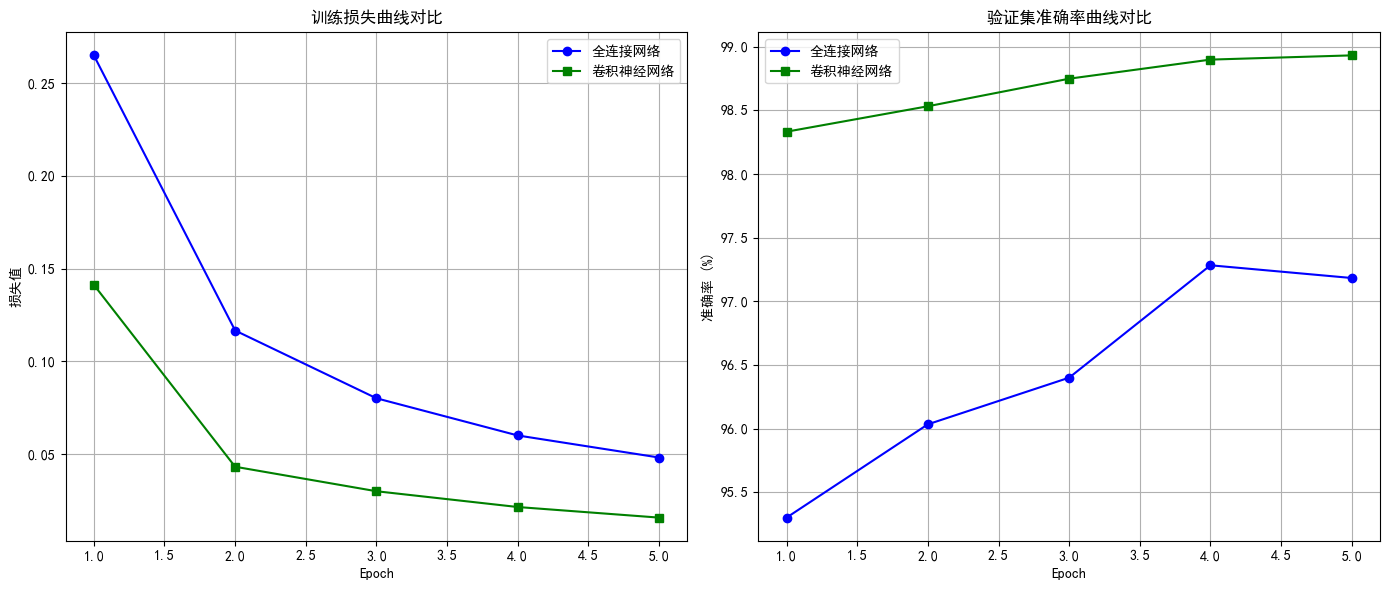

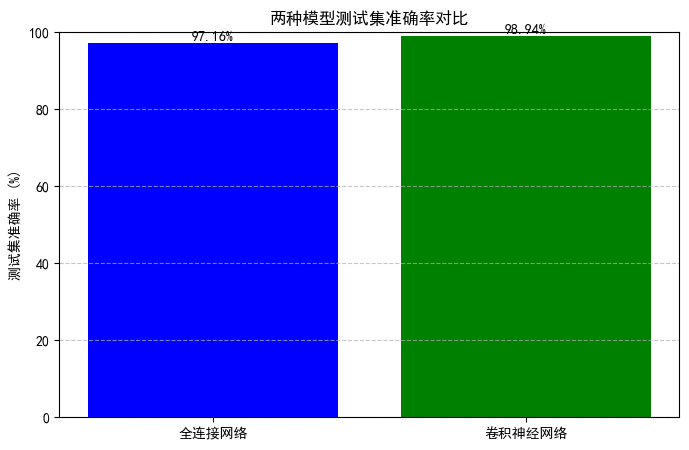


模型性能总结:
全连接网络 - 测试集准确率: 97.16%
卷积神经网络 - 测试集准确率: 98.94%
卷积神经网络表现更好，准确率高出 1.78 个百分点


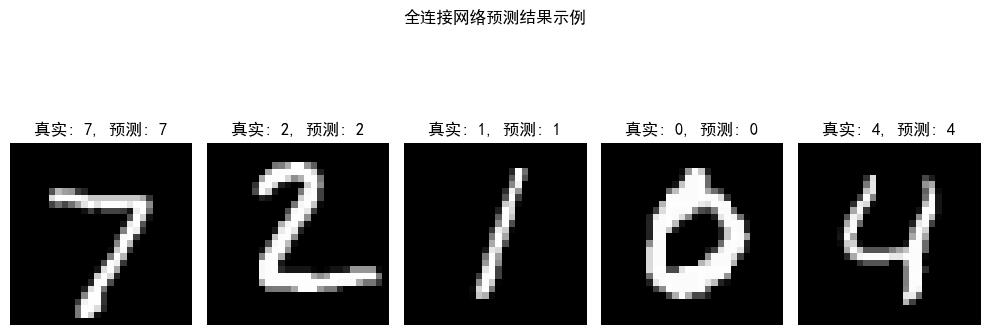

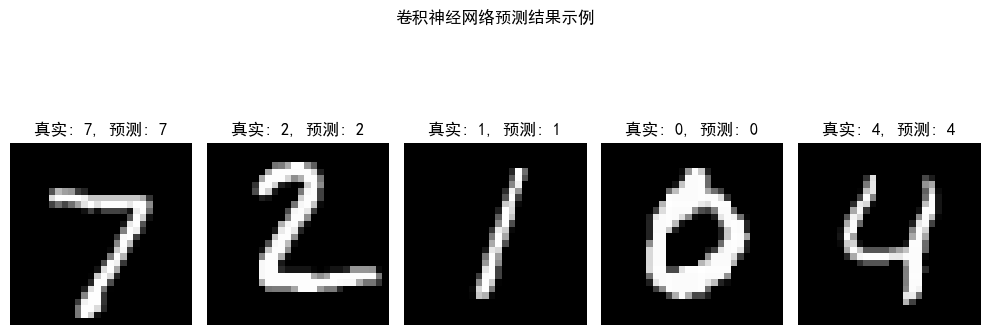

In [2]:
main()

使用设备: cuda

===== 测试自定义图片: ../data/test_digits/7.png =====
全连接网络预测结果:


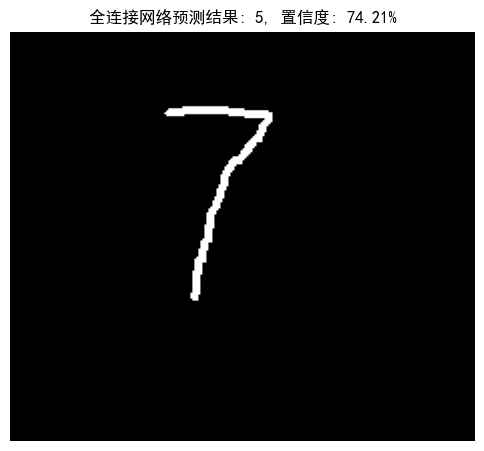

全连接网络: 预测结果 5, 置信度 74.21%

卷积神经网络预测结果:


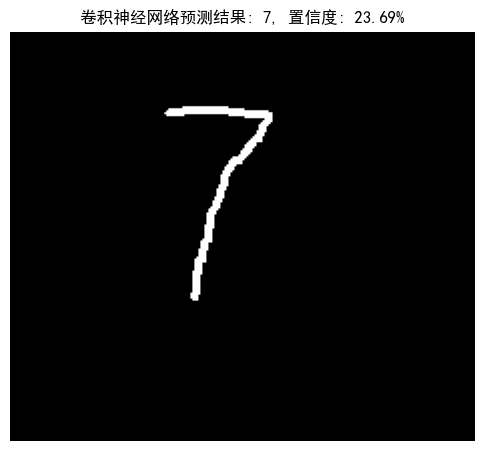

卷积神经网络: 预测结果 7, 置信度 23.69%


In [3]:
# 测试自定义图片（如果有示例图片）
# 模型保存路径
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'使用设备: {device}')

fc_model_path = 'models/best_fc_model.pth'
cnn_model_path = 'models/best_cnn_model.pth'

best_fc_model = load_model('fc', fc_model_path, device=device)
best_cnn_model = load_model('cnn', cnn_model_path, device=device)

example_image_path = '../data/test_digits/7.png'  # 示例图片路径
if os.path.exists(example_image_path):
        print(f"\n===== 测试自定义图片: {example_image_path} =====")
        print("全连接网络预测结果:")
        fc_pred, fc_conf = visualize_custom_prediction(best_fc_model, example_image_path, device, "全连接网络")
        print(f"全连接网络: 预测结果 {fc_pred}, 置信度 {fc_conf:.2f}%")
        
        print("\n卷积神经网络预测结果:")
        cnn_pred, cnn_conf = visualize_custom_prediction(best_cnn_model, example_image_path, device, "卷积神经网络")
        print(f"卷积神经网络: 预测结果 {cnn_pred}, 置信度 {cnn_conf:.2f}%")
else:
        print(f"\n提示: 未找到示例图片 {example_image_path}")
        print("请将您的手写数字图片放在相应目录下，或修改example_image_path变量指向您的图片")